In [1]:
#!/usr/bin/env python3
import os, sys, pandas as pd
import matplotlib.pyplot as plt
import re, ast
from math import ceil, sqrt
import seaborn as sns

In [2]:
parent = ""
all_folders = [f for f in os.listdir() if os.path.isdir(f)]

def base_name(folder):
        """Return the experiment base name (everything before the first underscore).

        Examples:
            'exp2' -> 'exp2'
            'exp2_fr' -> 'exp2'
            'exp2_500_1000' -> 'exp2'
        """
        return folder.split('_', 1)[0]

groups = {}
for f in all_folders:
    b = base_name(f)
    groups.setdefault(b, []).append(f)

groups

{'apoptosis': ['apoptosis_synthetic'],
 'exp0': ['exp0', 'exp0_fr', 'exp0_noise', 'exp0_r33', 'exp0_r66'],
 'exp1': ['exp1', 'exp1_fr', 'exp1_r33', 'exp1_r66'],
 'exp2': ['exp2',
  'exp2_eq',
  'exp2_eq_dense',
  'exp2_eq_extradense',
  'exp2_fc',
  'exp2_fr',
  'exp2_hub',
  'exp2_r33',
  'exp2_r66',
  'exp2_sl'],
 'exp3': ['exp3_500_1000',
  'exp3_500_1250',
  'exp3_500_2000',
  'exp3_500_550',
  'exp3_500_800'],
 'exp4': ['exp4_1000_2000',
  'exp4_100_200',
  'exp4_250_500',
  'exp4_500_1000',
  'exp4_600_1200'],
 'exp5': ['exp5_s1000',
  'exp5_s10000',
  'exp5_s2500',
  'exp5_s3500',
  'exp5_s500',
  'exp5_s5000',
  'exp5_s7500',
  'exp5_s9000'],
 'exp6': ['exp6_s10000_eqd',
  'exp6_s2500_eqd',
  'exp6_s5000_eqd',
  'exp6_s7500_eqd'],
 'exp7': ['exp7_25000'],
 'exp': ['exp_test'],
 'expsi': ['expsi_rcp', 'expsi_si'],
 'og': ['og_pdgrapher_data', 'og_pdgrapher_data_fr'],
 'old': ['old'],
 'old exp1': ['old exp1'],
 'pathway': ['pathway_no_fold', 'pathway_no_nd', 'pathway_synthetic']

In [3]:
ideal_groups = {
 'exp4': ['exp4_100_200', 'exp4_250_500','exp4_500_1000', 'exp4_600_1200'],
 'ref': ['ref_1']}

# sort groups to match ideal_groups. if there is a missing folder, dont add it, but print a warning
for key in ideal_groups:
    if key in groups:
        ideal_order = ideal_groups[key]
        actual_folders = groups[key]
        sorted_folders = []
        for folder in ideal_order:
            if folder in actual_folders:
                sorted_folders.append(folder)
            else:
                print(f"Warning: missing folder '{folder}' in group '{key}'")
        groups[key] = sorted_folders

groups

{'apoptosis': ['apoptosis_synthetic'],
 'exp0': ['exp0', 'exp0_fr', 'exp0_noise', 'exp0_r33', 'exp0_r66'],
 'exp1': ['exp1', 'exp1_fr', 'exp1_r33', 'exp1_r66'],
 'exp2': ['exp2',
  'exp2_eq',
  'exp2_eq_dense',
  'exp2_eq_extradense',
  'exp2_fc',
  'exp2_fr',
  'exp2_hub',
  'exp2_r33',
  'exp2_r66',
  'exp2_sl'],
 'exp3': ['exp3_500_1000',
  'exp3_500_1250',
  'exp3_500_2000',
  'exp3_500_550',
  'exp3_500_800'],
 'exp4': ['exp4_100_200', 'exp4_250_500', 'exp4_500_1000', 'exp4_600_1200'],
 'exp5': ['exp5_s1000',
  'exp5_s10000',
  'exp5_s2500',
  'exp5_s3500',
  'exp5_s500',
  'exp5_s5000',
  'exp5_s7500',
  'exp5_s9000'],
 'exp6': ['exp6_s10000_eqd',
  'exp6_s2500_eqd',
  'exp6_s5000_eqd',
  'exp6_s7500_eqd'],
 'exp7': ['exp7_25000'],
 'exp': ['exp_test'],
 'expsi': ['expsi_rcp', 'expsi_si'],
 'og': ['og_pdgrapher_data', 'og_pdgrapher_data_fr'],
 'old': ['old'],
 'old exp1': ['old exp1'],
 'pathway': ['pathway_no_fold', 'pathway_no_nd', 'pathway_synthetic'],
 'pdgrapher': ['pdgraphe

In [4]:
def extract_metric(row, metric_path, pdg_metric:bool = False):
    """Extract nested metric, falling back to top-level column."""
    keys = metric_path.split(".")
    try:
        value = row
        for k in keys:
            if isinstance(value, str):
                try:
                    value = ast.literal_eval(value)
                except Exception:
                    return None
            if pdg_metric:
                value = value.get('pdgrapher_perturbation_discovery', None) if isinstance(value, dict) else None
            value = value.get(k, None) if isinstance(value, dict) else None
            if value is None:
                break
        if value is not None:
            return value
    except Exception:
        pass
    return row.get(keys[-1], None)

In [5]:
MODEL_COLOR_MAP = {
    "pdgrapher": "#1f77b4",          # blue
    "pdgraphernognn": "#9467bd",     # purple
    "random": "#d62728",             # red
    "overlap": "#ff7f0e",            # orange
    "smallestSuperset": "#2ca02c",   # green
    "advanced_random": "#8c564b",    # brown
}

DEFAULT_COLOR = "#7f7f7f"

def get_model_color(model_type: str):
    return MODEL_COLOR_MAP.get(model_type, DEFAULT_COLOR)


label_dict = {
    "base": "Noise-Free",
    "noise": "Noise (Ref)",
    "r33": "33% Random",
    "r66": "66% Random",
    "fr": "Random Barabasi",
    "sl": "Self-Loop",
    "eq": "Circular Graph",
    "hub": "Hub Graph",
    "sl": "Self-Loop Graph",
    "fc": "Fully Connected",
    "s500": "500 Samples",
    "s1000": "1000 Samples",
    "s5000": "5000 Samples",
    "s9000": "9000 Samples (Ref)",
    "s10000": "10000 Samples",
    "rcp": "RACIPE (Ref)",
    "si": "Susceptible-Infected",
    "pdgrapher": "PDG",
    "pdgraphernognn": "PDGNG",
}

y_lim_dict = {
    "avg rank of source": (0, 0.55),
    "source in top 20": (0, 0.2),
}

FIG_WIDTH = 8
FIG_HEIGHT = 5
AX_LEFT = 0.15
AX_BOTTOM = 0.2
AX_WIDTH = 0.75
AX_HEIGHT = 0.7
PALETTE = sns.color_palette("colorblind")

def create_fixed_axes():
    """Returns a figure and axes with fixed plotting area."""
    fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
    ax = fig.add_axes([AX_LEFT, AX_BOTTOM, AX_WIDTH, AX_HEIGHT])
    return fig, ax

def load_variant_dfs(exp: str, strict: bool = True):
    """Load dataframes for all variants of an experiment.
    Returns list of tuples (variant, df, num_nodes)."""
    assert exp in groups, f"Unknown experiment key: {exp}"
    dfs_info = []
    for v in groups[exp]:
        path = os.path.join(parent, v, "all_results.csv")
        if not os.path.exists(path):
            msg = f"Missing file for variant '{v}': {path}"
            if strict:
                raise FileNotFoundError(msg)
            else:
                print("Warning:", msg, "Skipping this variant.")
                continue
        df = pd.read_csv(path)
        if df is None or df.empty:
            msg = f"File '{path}' is empty or has no rows." 
            if strict:
                raise ValueError(msg)
            else:
                print("Warning:", msg, "Skipping this variant.")
                continue
        num_nodes = None
        if "num_nodes" in df.columns and df["num_nodes"].notna().any():
            num_nodes = df["num_nodes"].dropna().iloc[0]
        dfs_info.append((v, df, num_nodes))
    if not dfs_info and strict:
        raise ValueError(f"No available variants found for experiment '{exp}'.")
    return dfs_info


def compute_stats_per_variant(dfs_info, metric: str, normalize: bool = False):
    """Compute mean and std per model_type for each variant.
    Returns (available_variants, means_list, Refs_list, model_types_set)."""
    means_list,stds_list = [], []
    model_types_set = set()
    available_variants = []
    for v, df, num_nodes in dfs_info:
        vals = {}
        for mt, group in df.groupby("model_type"):
            metrics = []
            for r in group.to_dict(orient="records"):
                val = extract_metric(r, metric)
                if val is None:
                    continue
                if normalize:
                    if num_nodes is None:
                        raise ValueError(f"Cannot normalize variant '{v}' by num_nodes: num_nodes missing.")
                    val = float(val) / float(num_nodes)
                metrics.append(float(val))
            if metrics:
                s = pd.Series(metrics)
                vals[mt] = (s.mean(), s.std(ddof=0))
        if vals:
            means_list.append(pd.Series({k: v[0] for k, v in vals.items()}))
            stds_list.append(pd.Series({k: v[1] for k, v in vals.items()}))
            available_variants.append(v)
            model_types_set.update(vals.keys())
    return available_variants, means_list, stds_list, model_types_set


def select_model_types(model_types_set, preferred=None):
    """Return ordered list of model types to display. If preferred provided, use it but validate presence."""
    if preferred is None:
        preferred = ["pdgrapher", "overlap", "pdgraphernognn", "random"]
        # preferred = ["pdgrapher", "pdgraphernognn", "smallestSuperset", "overlap", "advanced_random", "random"]
    # keep only those in preferred and available set, but fail fast if none overlap
    selected = [m for m in preferred if m in model_types_set]
    if not selected:
        raise ValueError(f"No preferred model types found in data. Available: {sorted(model_types_set)}")
    return selected


In [6]:
def line_plot_metric(exp: str, metric: str, title: str = None, normalize: bool = False, preferred_model_types=None, strict: bool = True):
    """Plot a line chart with one line per model type for a given experiment."""
    dfs_info = load_variant_dfs(exp, strict=strict)
    if not dfs_info:
        raise ValueError(f"No variants found for experiment '{exp}'")

    available_variants, means_list, stds_list, model_types_set = compute_stats_per_variant(dfs_info, metric, normalize=normalize)
    if not available_variants:
        raise ValueError(f"No data found for metric '{metric}' in experiment '{exp}'")

    num_pattern = re.compile(r"\d+")
    suffix_nums = []
    max_len = 0
    for v in available_variants:
        suffix = v[len(exp) + 1:] if v.startswith(exp + '_') else v
        nums = [int(x) for x in num_pattern.findall(suffix)]
        suffix_nums.append(nums)
        max_len = max(max_len, len(nums))

    best_idx = None
    best_unique = -1
    for idx in range(max_len):
        vals = [nums[idx] if idx < len(nums) else None for nums in suffix_nums]
        unique_vals = len(set(v for v in vals if v is not None))
        if unique_vals > best_unique:
            best_unique = unique_vals
            best_idx = idx

    if best_idx is None or best_unique <= 1:
        raise ValueError(f"Cannot determine varying numeric component for experiment '{exp}'. Tokens: {suffix_nums}")

    x_vals = [nums[best_idx] if best_idx < len(nums) else float('nan') for nums in suffix_nums]

    model_types = select_model_types(model_types_set, preferred=preferred_model_types)

    model_names = {
        "overlap": "Jaccard",
        "random": "Random",
        "pdgrapher": "PDG",
        "pdgraphernognn": "PDGNG"
    }

    fig, ax = create_fixed_axes()

    any_plotted = False
    for j, mt in enumerate(model_types):
        pts = []
        for i, v in enumerate(available_variants):
            x = x_vals[i]
            y = means_list[i].get(mt, float('nan'))
            yerr = stds_list[i].get(mt, float('nan')) if stds_list[i] is not None else float('nan')
            if pd.isna(x) or pd.isna(y):
                continue
            pts.append((float(x), float(y), float(yerr) if not pd.isna(yerr) else float('nan')))

        if not pts:
            msg = f"No data for model_type '{mt}' in experiment '{exp}'."
            if strict:
                raise ValueError(msg)
            print("Warning:", msg, "Skipping.")
            continue

        pts.sort(key=lambda t: t[0])
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        errs = [p[2] for p in pts]

        ax.errorbar(
            xs, ys, yerr=errs,
            marker='o',
            label=model_names.get(mt, mt),
            color=get_model_color(mt),
            capsize=3
        )

        any_plotted = True

    if not any_plotted:
        raise ValueError(f"No plotted data for experiment '{exp}' and metric '{metric}'.")

    uniq_xs = sorted(set(x for x in x_vals if not pd.isna(x)))
    if uniq_xs:
        ax.set_xticks(uniq_xs)
        #xtick_labels = [f"500/{str(int(x))} (Ref)"  if x == 1000 else f"500/{str(int(x))}" for x in uniq_xs]
        xtick_labels = [f"{str(int(x))}/{str(int(x*2))} (Ref)"  if x == 500 else f"{str(int(x))}/{str(int(x*2))}" for x in uniq_xs]
        ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

    ax.set_xlabel('Nodes/Edges')
    ax.set_ylabel(("normalized " if normalize else "") + metric)
    ax.set_title(title if title is not None else f"{exp}: {metric}")
    ax.legend(loc='best', framealpha=0.5)

    fig.tight_layout()
    plt.show()

In [7]:
def scatter_ratio_plot(exp: str, metric: str, title: str = None,
                       normalize: bool = False,
                       strict: bool = True):

    dfs_info = load_variant_dfs(exp, strict=strict)
    if not dfs_info:
        raise ValueError(f"No variants found for experiment '{exp}'")

    available_variants, means_list, stds_list, model_types_set = \
        compute_stats_per_variant(dfs_info, metric, normalize=normalize)

    if not available_variants:
        raise ValueError(f"No data found for metric '{metric}' in experiment '{exp}'")

    # ------------------------------------------------------------
    # Extract varying numeric component (same logic as before)
    # ------------------------------------------------------------
    num_pattern = re.compile(r"\d+")
    suffix_nums = []
    max_len = 0

    for v in available_variants:
        suffix = v[len(exp) + 1:] if v.startswith(exp + '_') else v
        nums = [int(x) for x in num_pattern.findall(suffix)]
        suffix_nums.append(nums)
        max_len = max(max_len, len(nums))

    best_idx = None
    best_unique = -1
    for idx in range(max_len):
        vals = [nums[idx] if idx < len(nums) else None for nums in suffix_nums]
        unique_vals = len(set(v for v in vals if v is not None))
        if unique_vals > best_unique:
            best_unique = unique_vals
            best_idx = idx

    if best_idx is None or best_unique <= 1:
        raise ValueError(
            f"Cannot determine varying numeric component for experiment '{exp}'."
        )

    x_vals = [nums[best_idx] if best_idx < len(nums) else float('nan')
              for nums in suffix_nums]

    # ------------------------------------------------------------
    # Compute PDG / PDGNG ratio
    # ------------------------------------------------------------
    xs = []
    ratios = []

    for i, v in enumerate(available_variants):
        x = x_vals[i]
        pdg = means_list[i].get("pdgrapher", float('nan'))
        pdgng = means_list[i].get("pdgraphernognn", float('nan'))

        if pd.isna(x) or pd.isna(pdg) or pd.isna(pdgng) or pdgng == 0:
            continue

        xs.append(float(x))
        ratios.append(float(pdg) / float(pdgng))

    if not xs:
        raise ValueError("No valid ratio data found.")

    # Sort by x
    pts = sorted(zip(xs, ratios), key=lambda t: t[0])
    xs = [p[0] for p in pts]
    ratios = [p[1] for p in pts]

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = create_fixed_axes()

    ax.scatter(
        xs,
        ratios,
        s=80,
        edgecolors="black",
        linewidths=0.5
    )

    ax.axhline(1.0, linestyle="--")

    # ------------------------------------------------------------
    # Custom x tick labels
    # ------------------------------------------------------------
    uniq_xs = sorted(set(xs))
    if uniq_xs:
        ax.set_xticks(uniq_xs)
        xtick_labels = [
            f"{int(x)}/{int(x*2)} (Ref)" if x == 500
            else f"{int(x)}/{int(x*2)}"
            for x in uniq_xs
        ]
        ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

    ax.set_xlabel("Nodes/Edges")
    ax.set_ylabel("pdgrapher / pdgraphernognn")
    ax.set_title(title if title is not None else f"{exp}: ratio")

    fig.tight_layout()
    plt.show()


/tmp/ipykernel_674081/4108443754.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


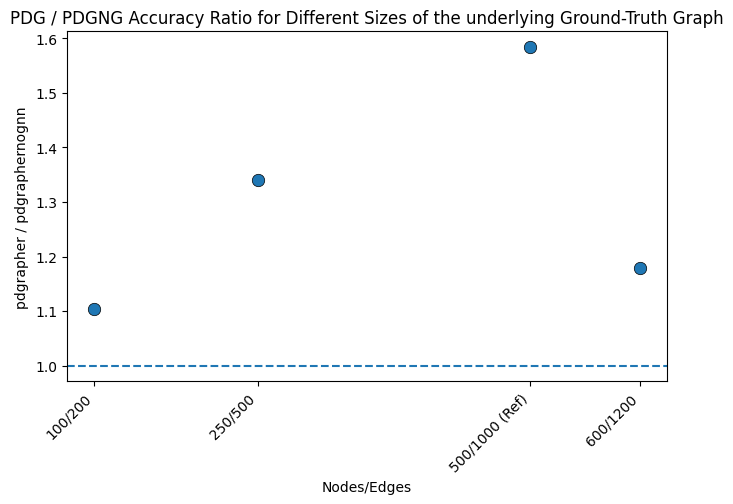

In [ ]:
scatter_ratio_plot('exp4', 'source in top 20', title='PDG / PDGNG top 20 Ratio for Different Sizes of the underlying Ground-Truth Graph')